# TS4 - Primeros pasitos en la estimación espectral



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

## Utilities de TS anteriores

### Generador de señales (TS-1)

In [2]:
class GeneradorSenales:

    @staticmethod
    def _resolver_parametros(ff, n, fs):
        """
        Resuelve fs y n en caso de no ser provistos
        (se trata de igualar fs y n, en caso de no haber valores de ambos -< se lleva a nyquist)
        """

        if fs is None and n is None:
            fs = ff * 2
            n = int(fs)

        elif fs is None:
            fs = n

        elif n is None:
            n = int(fs)

        return int(n), float(fs)

    @staticmethod
    def _generar_tiempo(n, fs):
        t = np.arange(n) / fs
        return t.reshape(-1, 1)

    @staticmethod
    def generar_seno(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

        return tt, xx

    @staticmethod
    def generar_cuadrada(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        xx = dc + vmax * np.sign(np.sin(2 * np.pi * ff * tt + ph))

        return tt, xx

    @staticmethod
    def generar_sawtooth(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        # Fase expresada en ciclos
        fase_ciclos = ff * tt + ph / (2 * np.pi)

        rampa_01 = fase_ciclos - np.floor(fase_ciclos)

        # Escalar a -1 1
        xx = dc + vmax * (2 * rampa_01 - 1)

        return tt, xx

### Implementación de la DFT (TS-2)

In [3]:
def mi_funcion_DFT(xx):
    """
    Calcula la DFT de una señal real.

    Parametros
    ----------
    xx : array_like (N,) o (N,1)
        Senial real a analizar.

    Retorna
    -------
    XX : ndarray (N,1) complejo
        DFT de xx.
    """
    x = np.asarray(xx, dtype=float)
    N = x.size

    n = np.arange(N)
    k = n.reshape(-1, 1)# Transpuesta
    n = n.reshape(1, -1)# convierto en matriz

    #@ = Producto matricial
    integer_matrix = k @ n
    W = np.exp(-1j * 2 * np.pi * integer_matrix / N)

    XX = W @ x
    return XX.reshape(-1, 1)

## Ejemplo de desparramo espectral


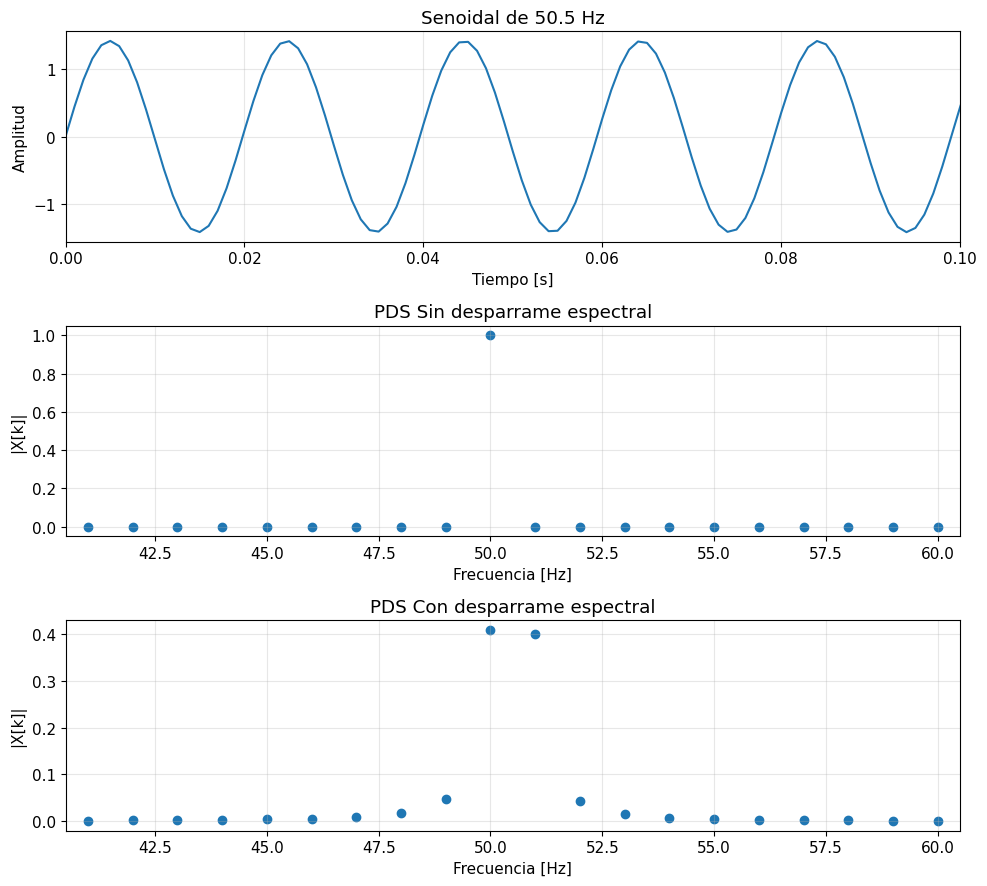

In [4]:

N = 1000
fs = 1000
f0 = 50
A = np.sqrt(2) # Potencia unitaria

def pds_maker(xx, tt):
    fs = 1/(tt[1] - tt[0])
    N = len(xx)
    XX = mi_funcion_DFT(xx)
    freqs = np.arange(N) * fs / N
    
    modulo = np.abs(XX)
    modulo = (modulo * modulo) / (len(modulo)*fs)
    modulo = 2 * modulo[:N//2]
    
    return freqs, modulo
    
######################### Señal SIN desparrame #########################
tt, xx = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)
freqs, modulo_correcto = pds_maker(xx, tt)
########################################################################

######################### Señal CON desparrame #########################
f0 = 50.5
tt, xx = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)
freqs, modulo_desparramado = pds_maker(xx, tt)
########################################################################

fig, axes = plt.subplots(3, 1, figsize=(10, 9))

axes[0].plot(tt, xx)
axes[0].set_title(f"Senoidal de {f0} Hz")
axes[0].set_xlabel("Tiempo [s]")
axes[0].set_ylabel("Amplitud")
axes[0].set_xlim(0, 0.1)


axes[1].scatter(freqs[:N//2], modulo_correcto, marker="o")
axes[1].set_title("PDS Sin desparrame espectral")
axes[1].set_xlabel("Frecuencia [Hz]")
axes[1].set_ylabel("|X[k]|")
axes[1].set_xlim(f0 - 10, f0 + 10)

axes[2].scatter(freqs[:N//2], modulo_desparramado, marker="o")
axes[2].set_title("PDS Con desparrame espectral")
axes[2].set_xlabel("Frecuencia [Hz]")
axes[2].set_ylabel("|X[k]|")
axes[2].set_xlim(f0 - 10, f0 + 10)

plt.tight_layout()
plt.show()



Se observa claramente, como en la segunda señal (que estaria centrada en 50.5 hz) presenta componentes "fantasma" en frecuencias aledañas

a continuacion, se grafica el kernel de dirichlet, que es el causante de esta distorsion:

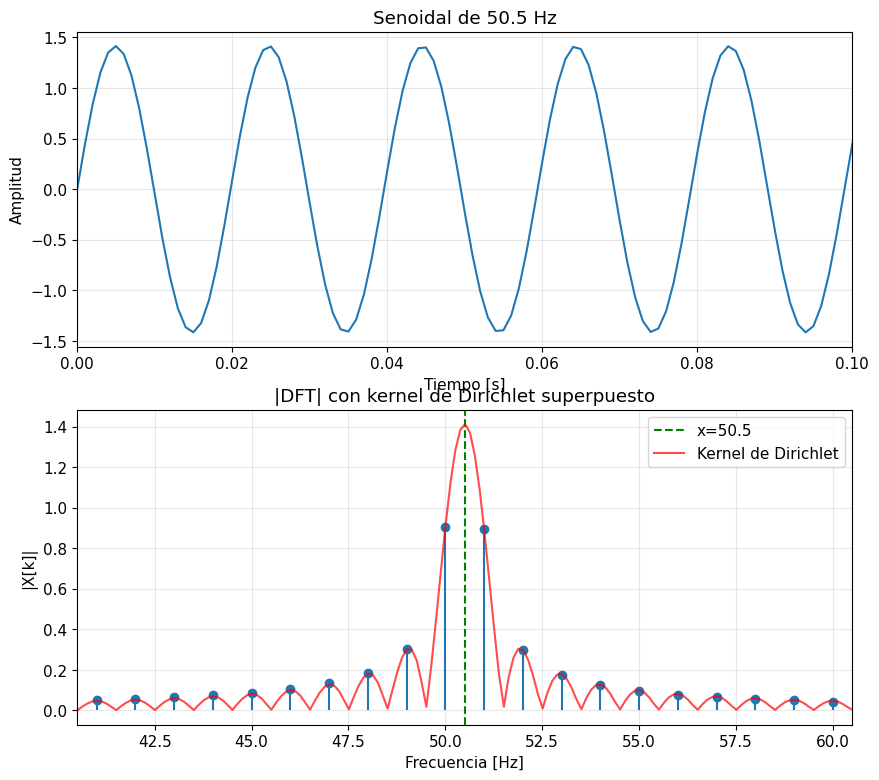

In [5]:

N = 1000
fs = 1000
A = np.sqrt(2)

######################### Señal CON desparrame #########################
f0 = 50.5
tt, xx = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)
XX = mi_funcion_DFT(xx)
modulo = 2 * np.abs(XX)[:N//2] / N

freqs = np.arange(N) * fs / N
########################################################################
############################ Armo el kernel ############################
h = np.linspace(0, fs/2, 4000) # espectro mucho mas denso (para que se vea lindo el kernel)
y = A  * np.abs(np.sinc((h - f0)) / np.sinc((h - f0) / N)) #Lo centro en f0! (desplazado por los delta etc etc)
########################################################################

fig, axes = plt.subplots(2, 1, figsize=(10, 9))

axes[0].plot(tt, xx)
axes[0].set_title(f"Senoidal de {f0} Hz")
axes[0].set_xlabel("Tiempo [s]")
axes[0].set_ylabel("Amplitud")
axes[0].set_xlim(0, 0.1)


axes[1].stem(freqs[:N//2], modulo, basefmt=" ")
axes[1].axvline(x=f0, color='g', linestyle='--', label=f'x={f0}')
axes[1].plot(h, y, 'r-', alpha=0.7, label="Kernel de Dirichlet")
axes[1].set_title("|DFT| con kernel de Dirichlet superpuesto")
axes[1].set_xlabel("Frecuencia [Hz]")
axes[1].set_ylabel("|X[k]|")
axes[1].set_xlim(f0 - 10, f0 + 10)

axes[1].legend()


Se observa cómo el kernel de dirichlet (que aparece de observar la señal a traves de una ventana rectangular) coincide perfectamente con las muestras de la DFT. Es decir, el espectro discreto que se ve es simplemente el muestreo de este kernel.

Cuando $f_0$ cae exactamente en un bin, las muestras caen en los ceros del kernel y solo sobrevive una. Cuando cae entre bins, todas las "patas" del kernel se hacen visibles, apareciendo asi el desparramo espectral.

---

A continuación analizamos cómo afecta el desparramo cuando la frecuencia de la señal cae entre dos bins de la grilla espectral (caso desintonizado).

SEÑAL DE F0 = 250.0
la potencia es 1.0000000000000127

SEÑAL DE F0 = 250.25
la potencia es 0.9989979968559359

SEÑAL DE F0 = 250.5
la potencia es 0.9999999748670512



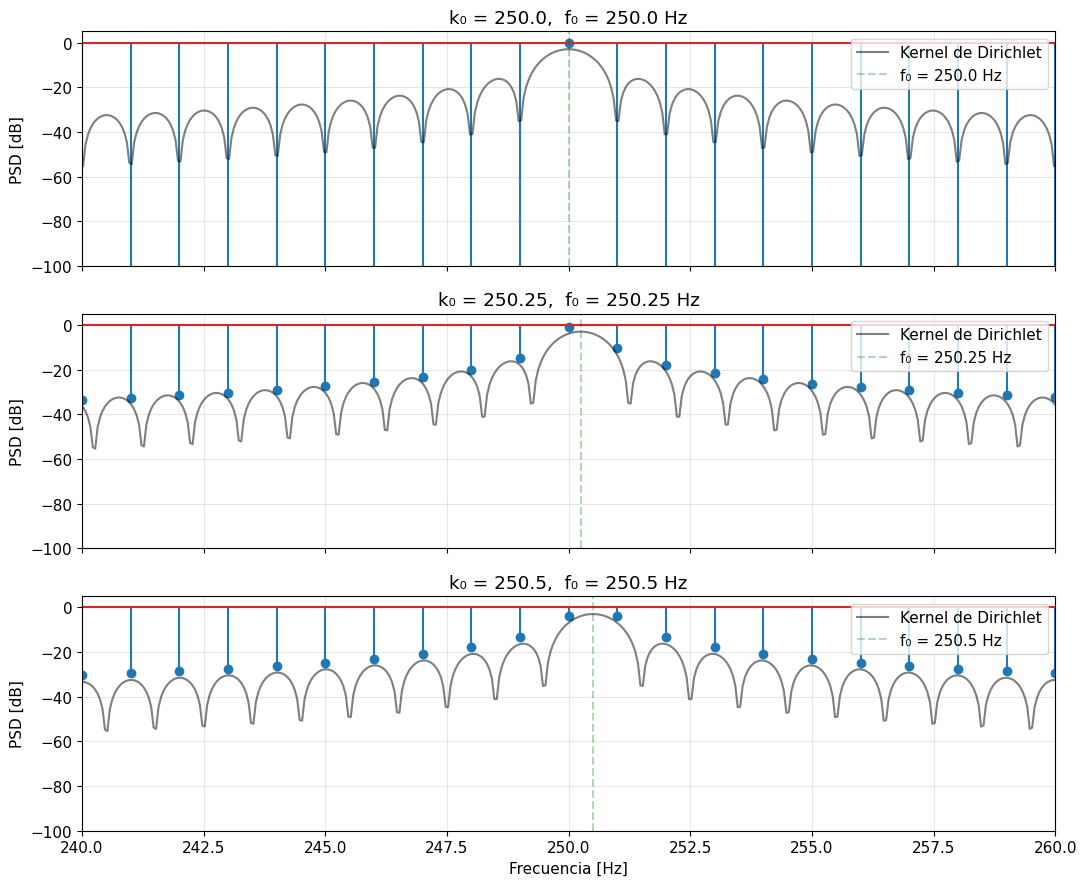

In [7]:
N = 1000
fs = 1000
df = fs / N   # res espec = 1 Hz
A = np.sqrt(2)   # Pot unitaraia

def generate_kernel(f0, fs): # Asume fs = n
    h = np.linspace(0, fs/2, fs * 10) 
    y = A * N * np.abs(np.sinc((h - f0)) / np.sinc((h - f0) / fs)) /2 
    y = (y **2) / (fs * fs) # por que asume fs = N
    y = 10 * np.log10(y + 1e-200)
    return h, y

k0_vals = np.asarray([N/4, N/4 + 0.25, N/4 + 0.5])
f0_vals = np.asarray([N/4, N/4 + 0.25, N/4 + 0.5]) * df # 250, 250.25, 250.5 Hz

freqs = np.arange(N) * fs / N

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

for ax, k0, f0 in zip(axes, k0_vals, f0_vals):
    tt, xx = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)
    XX = mi_funcion_DFT(xx)

    PSD = ((np.abs(XX)) ** 2) / (N * fs) # N = fs

    PSD_one = PSD[:N//2] * 2
    freqs_one = freqs[:N//2]
    PSD_db = 10 * np.log10(PSD_one + 1e-20)

    h, y = generate_kernel(f0, fs) # Mostramos el kernel por encima
    print(f"SEÑAL DE F0 = {f0}")
    print(f"la potencia es {PSD_one.sum()}")
    print()
    ax.stem(freqs_one, PSD_db)
    ax.plot(h, y, 'black', alpha=0.5, label="Kernel de Dirichlet")
    
    ax.axvline(f0, color='g', ls='--', alpha=0.3, label=f'f₀ = {f0} Hz')
    ax.set_title(f'k₀ = {k0},  f₀ = {f0} Hz')
    ax.set_ylabel('PSD [dB]')
    ax.set_xlim(240, 260)
    ax.set_ylim(-100, 5)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Frecuencia [Hz]')
plt.tight_layout()
plt.show()

Notese que, en esta comparación, el desparramo de la señal coincide exactamente con la PSD de la ventana rectangular (kernel) trasladada y centrada en $f_0$. 

*Nota: el kernel en gris esta graficado con alta densidad de puntos a modo ilustrativo, para visualizar su forma. En la DFT real, el kernel solo está muestreado en los N bins graficados en azul*

Se verifica ademas que la potencia se mantiene unitaria en los tres casos analizados (ver prints)

## BONUS - Zero Padding

k0          P temporal        Potencia            Potencia (con pad)  
----------------------------------------------------------------------
250.0       1.000000          1.000000            1.000000            
250.25      0.999000          0.999000            0.999000            
250.5       1.000000          1.000000            1.000000            


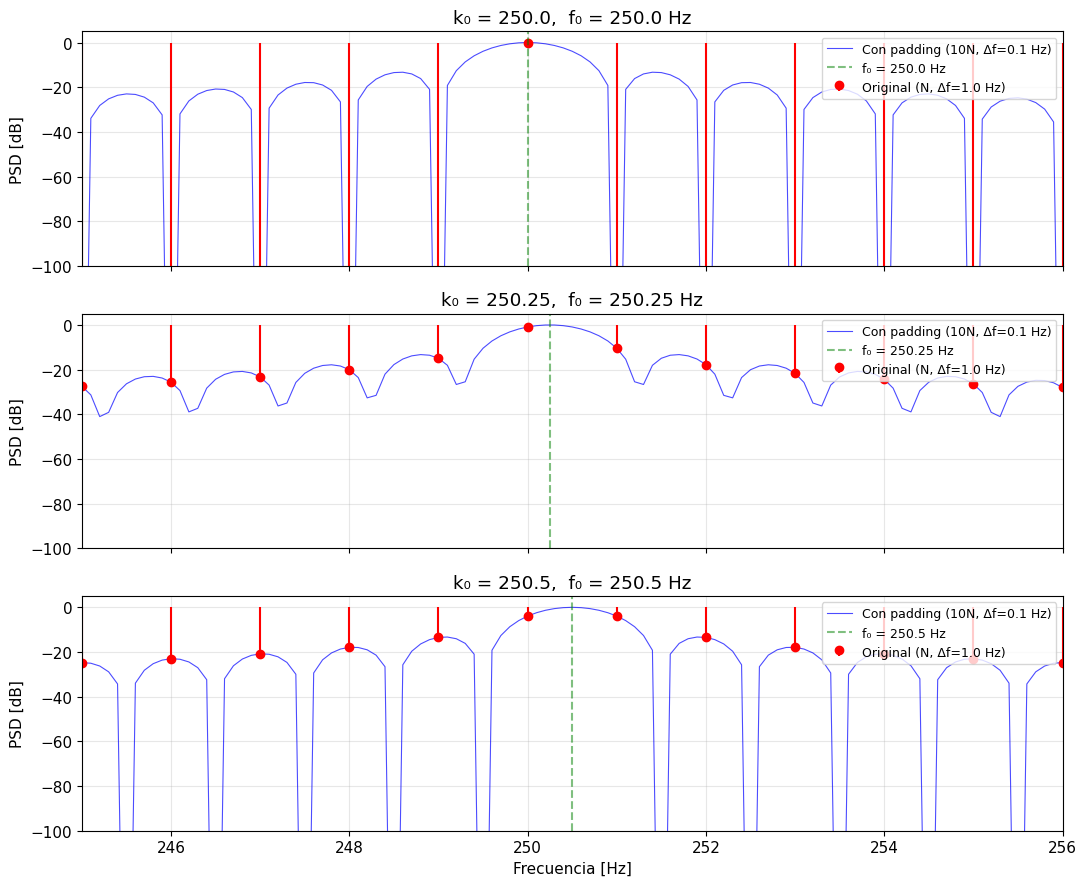

In [15]:
N  = 1000
fs = 1000
df = fs / N
A  = np.sqrt(2)        # amplitud para potencia unitaria

N_pad   = 9 * N        # ceros a agregar 
N_total = N + N_pad    # 10*N
df_pad  = fs / N_total # df "ficticio" = 0.1 Hz

k0_vals = np.array([N/4, N/4 + 0.25, N/4 + 0.5])
f0_vals = k0_vals * df

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# Tablitass
print(f"{'k0':<12}{'P temporal':<18}{'Potencia':<20}{'Potencia (con pad)':<20}")
print("-" * 70)

for ax, k0, f0 in zip(axes, k0_vals, f0_vals):
    # ---------- Señal original ----------
    tt, xx = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)
    xx = xx.flatten()

    # ---------- DFT sin padding ----------
    XX  = mi_funcion_DFT(xx).flatten()
    PSD = (np.abs(XX)**2) / (N * fs)
    PSD_one = 2 * PSD[:N//2]
    freqs   = np.arange(N//2) * fs / N
    PSD_db  = 10*np.log10(PSD_one + 1e-200)

    # ---------- DFT con padding ----------
    xx_pad = np.concatenate([xx, np.zeros(N_pad)]) # Agrego el padding
    XX_pad = np.fft.fft(xx_pad)
    PSD_pad = (np.abs(XX_pad)**2) / (N * fs) # IMPORTANTE: Dividir por N original pq sino da horrible (el zero padding solo da resolucion espectral, no deberia afectar la potencia de la señal)
    PSD_pad_one = 2 * PSD_pad[:N_total//2]
    freqs_pad   = np.arange(N_total//2) * fs / N_total
    PSD_pad_db  = 10*np.log10(PSD_pad_one + 1e-200)

    # ---------- Verif de potencia ----------
    P_temporal = np.mean(xx**2)  * 1             
    P_psd      = np.sum(PSD)     * df        
    P_psd_pad  = np.sum(PSD_pad) * df_pad
    print(f"{k0:<12}{P_temporal:<18.6f}{P_psd:<20.6f}{P_psd_pad:<20.6f}") 

    # ---------- Ploteos----------
    ax.plot(freqs_pad, PSD_pad_db, 'b-', lw=0.8, alpha=0.7,
            label=f'Con padding (10N, Δf={df_pad} Hz)')
    ax.stem(freqs, PSD_db, linefmt='r-', markerfmt='ro', basefmt=' ',
            label=f'Original (N, Δf={df} Hz)')
    ax.axvline(f0, color='g', ls='--', alpha=0.5, label=f'f₀ = {f0} Hz')
    ax.set_title(f'k₀ = {k0},  f₀ = {f0} Hz')
    ax.set_ylabel('PSD [dB]')
    ax.set_xlim(245, 256)
    ax.set_ylim(-100, 5)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Frecuencia [Hz]')
plt.tight_layout()
plt.show()

### Conclusion

Al agregar 9N ceros a la señal, nos queda una resolución espectral aparente de $fs/(10·N) = 0.1 Hz$. Por ello, en los gráficos se puede ver una representación mucho más definida y continua del espectro, evidenciando claramente la forma del kernel de Dirichlet alrededor de cada $f_0$.

Sin embargo, es importante aclarar que ninguna información adicional se agrega: el zero padding únicamente interpola la FFT (que ya estaba completamente determinada por las N muestras originales) para poder visualizar más claramente los lóbulos en el dominio de la frecuencia.

Esto quiere decir que, con una señal multitono cuyos lóbulos principales se solapen debido a una resolución original baja, el método no puede recuperar la información perdida. Si dos senoidales están separadas por menos de $\Delta f  = fs/N$, sus lóbulos se fusionan en uno solo indistinguible de un tono aislado. La verdadera resolución espectral está limitada por la duración temporal de la observación $T = N/fs$ (como confirmacion de esto, se deja un script adicional que demuestra este defecto)

Por último, se destaca que la potencia se conserva unitaria en los tres casos analizados.

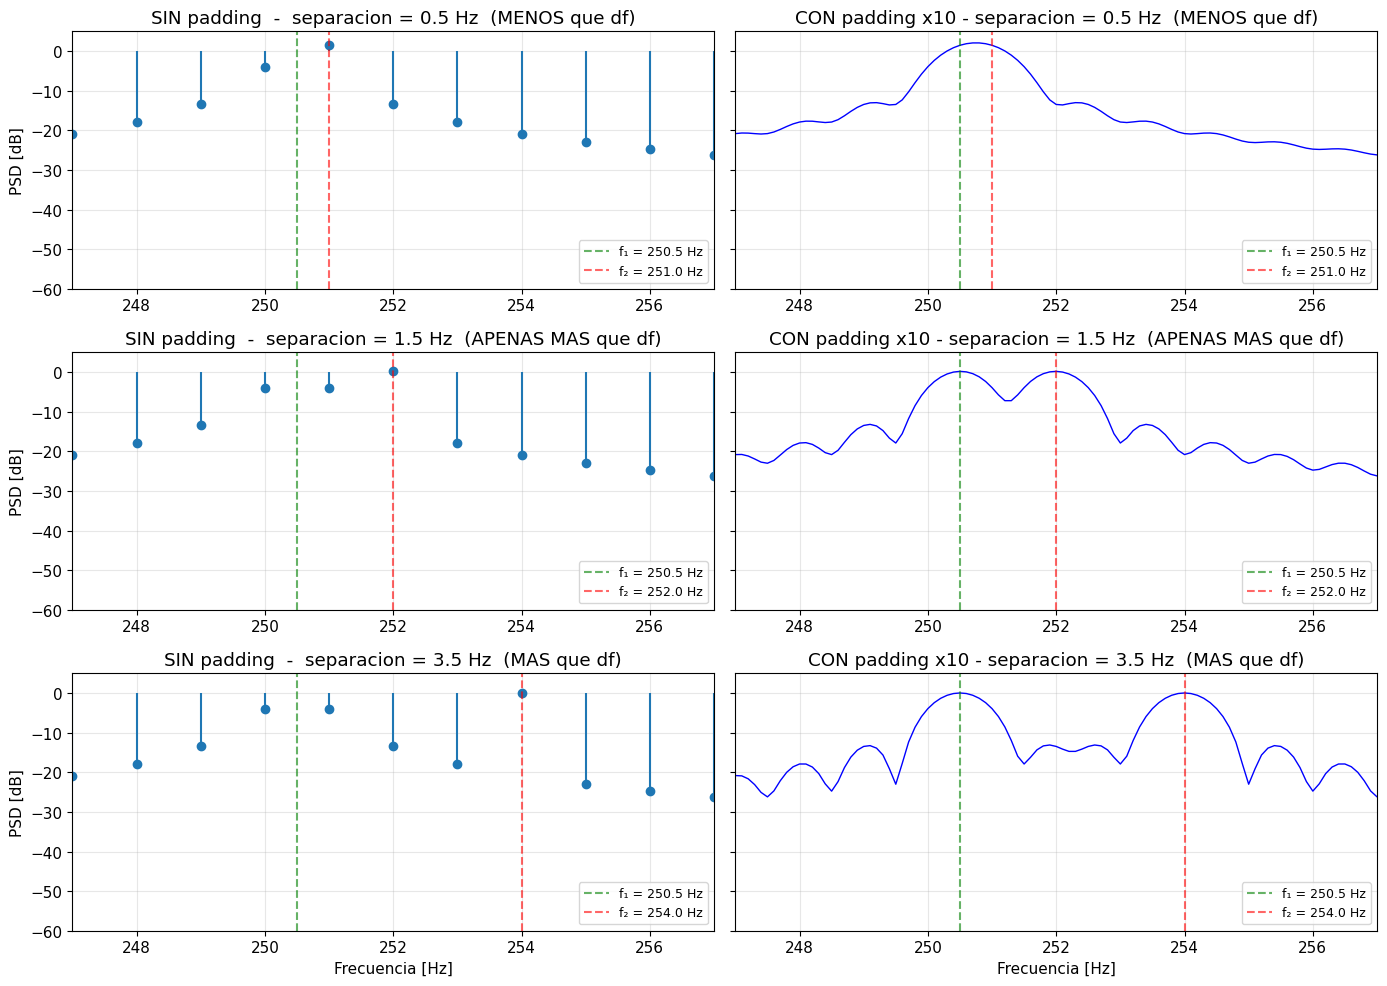

In [19]:
# ------------ Parametros ------------
N, fs   = 1000, 1000
df      = fs / N           # resolución real = 1 Hz
A       = np.sqrt(2)       # potencia unitaria (en ambos senos)
PAD     = 10               # padding
N_pad   = PAD * N
F_ANCLA = 250.5            # frec. fija de un seno

separaciones = [
    (0.5, "MENOS que df"),
    (1.5, "APENAS MAS que df"),
    (3.5, "MAS que df"),
]

# ------------ Helpers ------------
def sumador_senos(f1, f2, t, A=np.sqrt(2)):
    """Suma de dos senoidales"""
    return A * (np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t))

def psd_db(x, fs, N_norm, padding=None):
    """PSD de banda unica en dB. n_fft > len(x) => zero padding."""
    n_fft = padding or len(x)
    if padding != None:
        x = np.concatenate([x, np.zeros(n_fft - len(x))])
    X        = np.fft.fft(x)
    PSD      = (np.abs(X)**2) / (N_norm * fs)
    PSD_one  = 2 * PSD[:n_fft // 2]
    freqs    = np.arange(n_fft // 2) * fs / n_fft
    return freqs, 10 * np.log10(PSD_one + 1e-200)

def marcar_frecuencias(ax, f1, f2):
    ax.axvline(f1, color='g', ls='--', alpha=0.6, label=f'f₁ = {f1} Hz')
    ax.axvline(f2, color='r', ls='--', alpha=0.6, label=f'f₂ = {f2} Hz')

def estilizar(ax, titulo, xlim=(247, 257), ylim=(-60, 5)):
    ax.set_title(titulo)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

# ------------ Main ------------
t = np.arange(N) / fs
fig, axes = plt.subplots(len(separaciones), 2, figsize=(14, 10), sharey='row')

for row, (delta, comentario) in enumerate(separaciones):
    f1 = F_ANCLA
    f2 = F_ANCLA + delta
    
    x = sumador_senos(f1, f2, t, A)

    f_orig, psd_orig = psd_db(x, fs, N_norm=N)
    f_pad,  psd_pad  = psd_db(x, fs, N_norm=N, padding=N_pad)

    # Sin padding
    ax_l = axes[row, 0]
    ax_l.stem(f_orig, psd_orig, basefmt=' ')
    marcar_frecuencias(ax_l, f1, f2)
    estilizar(ax_l, f'SIN padding  -  separacion = {delta} Hz  ({comentario})')
    ax_l.set_ylabel('PSD [dB]')

    # Con padding
    ax_r = axes[row, 1]
    ax_r.plot(f_pad, psd_pad, 'b-', lw=1)
    marcar_frecuencias(ax_r, f1, f2)
    estilizar(ax_r, f'CON padding x{PAD} - separacion = {delta} Hz  ({comentario})')

axes[-1, 0].set_xlabel('Frecuencia [Hz]')
axes[-1, 1].set_xlabel('Frecuencia [Hz]')


plt.tight_layout()
plt.show()